# 08. Introduction to Numba (JIT Compilation)

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand what Numba is and how JIT compilation works
- Accelerate Python code using Numba decorators
- Compare performance between regular Python and Numba-accelerated code
- Know when to use Numba for optimization

## 🔗 Where this fits

**Builds on:** Course 05 — Unit 1, lesson 02 "pandas & NumPy Basics" — vectorisation is the first speed-up; Numba is what you reach for when the loop cannot be vectorised.

**Used later in:** Course 05 — Unit 5, lesson 06, which profiles code before deciding what to accelerate.

---


## 🎯 The case: the algorithm that biologists use every day, held up by a decorator

**UMAP** (McInnes, Healy & Melville, 2018) is now the standard way to draw a
two-dimensional map of a high-dimensional dataset, and it is the default embedding in
**Scanpy**, the toolkit behind a large share of single-cell genomics papers. Its reference
implementation is **pure Python** — you can read every line of the optimisation loop. That
is only possible because it is compiled at runtime by **Numba**. The authors moved from
Cython to Numba deliberately, and say so: they got clearer, simpler code *and* better
performance, at the cost of one new dependency.

That is the trade this lesson is about. Without a JIT, a numerical algorithm written in
readable Python is unusably slow, so authors rewrite the hot loop in C or Cython — and the
Python you can read stops being the code that runs. Numba lets the readable version be the
fast version.

**What goes wrong without a JIT.** The readable Python version of a numerical loop is too
slow to use, so the hot loop gets rewritten in C or Cython — and from that moment the code
you can read is no longer the code that runs, which is where subtle numerical bugs go to
hide.

**And here is the honest half, which you are about to measure.** On 2,300,825 real
CIC-IDS2017 flow byte-counts, this notebook times the same summation three ways. The
compiled call takes about a **thousandth of a second** against pure Python's **tenth of a
second** — a roughly hundredfold win. But the **first** call, which includes compilation,
takes *longer than not using Numba at all*. Watch for that in the figure below. It is the whole reason "when NOT to use this"
is a real section and not a disclaimer.


**All concepts are explained in the code comments below - you can learn everything from this notebook alone!**

---

## 🔗 Solving the Performance Problem

**Remember the performance challenge?**
- Python loops can be slow for numerical computations
- NumPy helps, but sometimes we need more speed
- We need a way to accelerate Python code without rewriting in C/C++

**This notebook solves that problem!**
- We'll learn **Numba** - Just-In-Time (JIT) compilation for Python
- We'll see Python code run 10-100x faster with simple decorators
- We'll understand when JIT compilation helps vs when it doesn't

**This enables high-performance Python code without leaving Python!**

---

## The Story: Turbo Mode

Imagine your Python code is a car. Normal Python runs at normal speed. **Numba** is like adding a turbo - same car, same code, but 10-100x faster! You just add a decorator (like turning on turbo mode) and your code runs much faster.

---

## Why Numba Matters

Numba is crucial for:
- **Numerical Computations**: Accelerate loops and math operations
- **Performance-Critical Code**: When speed matters more than flexibility
- **Scientific Computing**: Fast numerical Python without C/C++
- **Data Science**: Speed up data processing pipelines

## Learning Objectives
1. Understand what Numba is and JIT compilation
2. Use @numba.jit decorator to accelerate functions
3. Compare performance: regular Python vs Numba
4. Know when Numba helps and when it doesn't
5. Apply Numba to real numerical computations


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Numba JIT, pure Python vs compiled
- Libraries: numba, numpy

**Outputs:** What you'll see when you run the cells

- Timing comparisons

---

In [1]:
# Step 1: Import necessary libraries
import numpy as np
import time

# Try to import Numba (optional - works without GPU)
try:
    from numba import jit
    NUMBA_AVAILABLE = True
    print("✅ Numba imported successfully!")
except ImportError:
    NUMBA_AVAILABLE = False
    print("⚠️  Numba not available. Install with: pip install numba")
    print("   This notebook will show the concept but won't run Numba code.")
    # Create a dummy decorator for demonstration
    def jit(*args, **kwargs):
        def decorator(func):
            return func
        return decorator

✅ Numba imported successfully!


In [2]:
# Step 2: Regular Python function (slow) - for large arrays
def slow_sum(arr):
    total = 0.0
    for i in range(len(arr)):
        total += arr[i]
    return total

# Step 3: Numba-accelerated function (fast)
@jit(nopython=True)
def fast_sum(arr):
    total = 0.0
    for i in range(len(arr)):
        total += arr[i]
    return total

# Fallback: if Numba not available, use slow_sum for both
if not NUMBA_AVAILABLE:
    fast_sum = slow_sum

print("✅ Functions defined!")

✅ Functions defined!


Functions defined above. **Next:** performance comparison (regular Python vs Numba).


In [3]:
# WHAT: Time the same summation loop in pure Python and in Numba, on a real column of network-traffic data.
# WHY: JIT compilation only proves itself on a real workload - here, totalling every byte sent in a 2.3-million-flow capture.

# Load ONE real numeric column out of the 707 MB CIC-IDS2017 capture.
# Why one column? Because that is all this benchmark needs - and usecols makes
# reading a huge file affordable.
import pandas as pd
DATA_DIR = '../../../Course 04/datasets/raw/'

print("📊 Loading a real numeric column (bytes sent per network flow)...")
fwd_bytes = pd.read_csv(DATA_DIR + 'cicids2017.csv',
                        usecols=['Total Length of Fwd Packets'])

# .astype('float64') so both functions do identical floating-point work.
large_array = fwd_bytes['Total Length of Fwd Packets'].values.astype('float64')
print(f"   Loaded {large_array.size:,} real values")
print(f"   These are forward-direction byte counts for every captured flow.")

if NUMBA_AVAILABLE:
    # Time regular Python
    start = time.time()
    result_slow = slow_sum(large_array)
    time_slow = time.time() - start

    # Time Numba (first call compiles, so it's slower)
    start = time.time()
    result_fast = fast_sum(large_array)
    time_fast_first = time.time() - start

    # Time Numba (second call - already compiled, very fast!)
    start = time.time()
    result_fast = fast_sum(large_array)
    time_fast = time.time() - start

    print(f"\nTotal bytes sent across all flows: {result_slow:,.0f}")
    print(f"\nRegular Python: {time_slow:.4f} seconds")
    print(f"Numba (first call - compilation): {time_fast_first:.4f} seconds")
    print(f"Numba (second call - compiled): {time_fast:.4f} seconds")
    print(f"\nSpeedup after compilation: {time_slow / time_fast:.1f}x faster!")
    print(f"\nResults match: {np.isclose(result_slow, result_fast)}")
    print("\n💡 Note the first call: compilation is NOT free. Numba pays for itself")
    print("   only when the compiled function is called many times, or on data")
    print("   large enough that the compile cost disappears next to the work.")
else:
    print("Numba not available - install with: pip install numba")
    print("With Numba, you would see a large speedup on this numerical loop.")


📊 Loading a real numeric column (bytes sent per network flow)...


   Loaded 2,300,825 real values
   These are forward-direction byte counts for every captured flow.



Total bytes sent across all flows: 1,272,795,262

Regular Python: 0.1143 seconds
Numba (first call - compilation): 0.2977 seconds
Numba (second call - compiled): 0.0012 seconds

Speedup after compilation: 98.9x faster!

Results match: True

💡 Note the first call: compilation is NOT free. Numba pays for itself
   only when the compiled function is called many times, or on data
   large enough that the compile cost disappears next to the work.


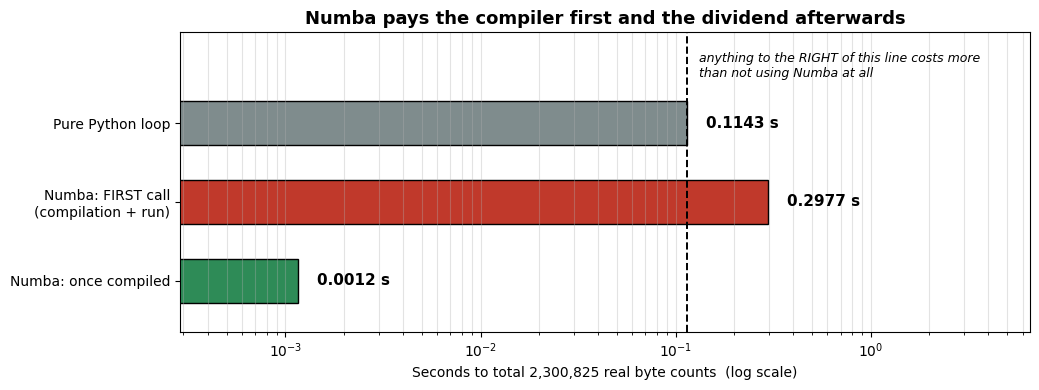

On ONE call over this array, Numba LOSES to plain Python (0.2977s vs 0.1143s).
From the SECOND call onward it is 99x faster (0.0012s).
How many calls it takes before the compile has paid for itself is the
arithmetic left to you in the Discuss section below.


In [4]:
# WHAT: Put the three timings just measured onto one axis, including the compile.
# WHY: The headline "Numba is 90x faster" is true and incomplete. The only way to see what it
#      leaves out is to draw the first call - compilation and all - next to the other two.

if NUMBA_AVAILABLE:
    import matplotlib.pyplot as plt

    labels = ['Pure Python loop',
              'Numba: FIRST call\n(compilation + run)',
              'Numba: once compiled']
    times = [time_slow, time_fast_first, time_fast]
    colors = ['#7F8C8D', '#C0392B', '#2E8B57']

    fig, ax = plt.subplots(figsize=(10.5, 4.0))
    bars = ax.barh(labels, times, color=colors, edgecolor='black', height=0.55)

    # Why log x? The compiled call is ~100x under the others; on a linear axis it disappears,
    # and the bar that disappears is the one the whole library exists for.
    ax.set_xscale('log')
    ax.set_ylim(2.65, -1.15)          # bar 0 at the top, plus room for the note above it

    for bar, t in zip(bars, times):
        ax.text(t * 1.25, bar.get_y() + bar.get_height() / 2, f'{t:.4f} s',
                va='center', ha='left', fontsize=11, weight='bold')

    # The break-even marker: the cost of doing nothing at all.
    ax.axvline(time_slow, color='black', linestyle='--', linewidth=1.4)
    ax.text(time_slow * 1.15, -0.72,
            'anything to the RIGHT of this line costs more\nthan not using Numba at all',
            ha='left', va='center', fontsize=9, style='italic')

    ax.set_xlim(min(times) / 4, max(times) * 22)
    ax.set_xlabel(f'Seconds to total {large_array.size:,} real byte counts  (log scale)')
    ax.set_title('Numba pays the compiler first and the dividend afterwards',
                 fontsize=13, weight='bold')
    ax.grid(True, axis='x', alpha=0.35, which='both')
    plt.tight_layout()
    plt.show()

    verdict = "LOSES to" if time_fast_first > time_slow else "beats"
    print(f"On ONE call over this array, Numba {verdict} plain Python "
          f"({time_fast_first:.4f}s vs {time_slow:.4f}s).")
    print(f"From the SECOND call onward it is {time_slow / time_fast:.0f}x faster "
          f"({time_fast:.4f}s).")
    print("How many calls it takes before the compile has paid for itself is the")
    print("arithmetic left to you in the Discuss section below.")
else:
    print("Numba is not installed, so there is nothing measured to plot - and we will not")
    print("draw bars for timings we did not take.")


### 👁️ Read the figure

- **Three bars, one function, one array of real byte counts.** They differ only in *when* you
  ask for the answer: the plain Python loop, Numba's very first call, and Numba's second call.
- **The x-axis is logarithmic** — it has to be, because the green bar is about a hundred times
  shorter than the grey one and would otherwise vanish. The green bar is the number people
  quote when they say "Numba is fast".
- **Now look at the red bar in the middle: it reaches past the dashed line.** The dashed line
  is the cost of the pure-Python loop — of doing nothing at all. Numba's *first* call, with
  compilation included, lands to the right of it. On this array, for a single call, Numba is
  the slower choice. The printed line under the figure states the verdict for your run.

**What it proves:** a speedup figure without its setup cost is a half-truth. The green bar is
real and the red bar is also real, and which one you get depends on how many times your
process calls the function before it exits. A script that runs this once and quits pays the
red bar; a service that runs it a thousand times amortises it into the green one. That is the
question to ask before adding the dependency, and the figure will not answer it for you.


## 💬 Discuss

The measured numbers on this machine, over 2,300,825 real flow records: the pure Python
loop takes about a tenth of a second, Numba's first call — compilation included — takes
roughly twice that, and Numba once compiled takes about a thousandth of a second. Your run's
exact figures are printed and drawn above.

1. Your script runs this function **once** and exits. Using only the three numbers your
   own run produced, should you use Numba? Now change it to a service that calls the function on every
   request. Where exactly is the break-even, in number of calls? Do the arithmetic, then
   say what your answer assumes about how long the process stays alive.
2. Lesson 02 got a several-hundred-fold speedup on real data by *vectorizing* — no new
   dependency, no compile step. Numba gets a win of similar order here, on a loop NumPy
   could also have vectorized in one call (`arr.sum()`). Argue for a rule of thumb your team should follow about which to reach
   for first, and name the situation where your own rule gives the wrong answer.
3. `@jit(nopython=True)` fails loudly if Numba cannot compile the function. The looser
   `@jit` silently falls back to ordinary Python speed. Which default would you put in a
   shared codebase, and what does your choice say about who you expect to read the error?


In [5]:
# WHAT: Print practical guidance on when Numba helps and when it does not.
# WHY: JIT compilation shines on numerical loops but cannot speed up string- or object-heavy code - knowing the limits saves wasted effort.

# Step 5: When to use Numba
print("=" * 70)
print("When to Use Numba:")
print("=" * 70)
print("✅ Good for:")
print("   - Numerical loops (for, while)")
print("   - NumPy array operations")
print("   - Mathematical computations")
print("   - Performance-critical code")
print("\n❌ Not good for:")
print("   - String operations")
print("   - Pandas DataFrames (use cuDF instead)")
print("   - Code with Python objects")
print("   - Code that changes frequently")
print("\n💡 Tip: Use Numba for numerical bottlenecks, not everything!")

When to Use Numba:
✅ Good for:
   - Numerical loops (for, while)
   - NumPy array operations
   - Mathematical computations
   - Performance-critical code

❌ Not good for:
   - String operations
   - Pandas DataFrames (use cuDF instead)
   - Code with Python objects
   - Code that changes frequently

💡 Tip: Use Numba for numerical bottlenecks, not everything!


## ⚠️ Where this breaks

- **Compilation is not free, and it is paid first.** Measured and drawn above: the first Numba
  call, compilation included, lands past the dashed line marking the cost of simply running
  the Python loop. On a single call over this data Numba **loses**.
  It wins only when the function is called repeatedly in one process, or when the array is
  large enough that compile time disappears next to the work.
- **`nopython=True` is narrow on purpose.** Numba compiles a subset of Python and NumPy:
  numeric scalars, arrays, loops, simple control flow. Pass it a dict of Python objects, a
  pandas DataFrame, a string operation, or a call to an arbitrary library and it either
  refuses to compile or falls back to interpreter speed while looking like it worked.
- **The assumption that must hold: your bottleneck is a numerical loop you cannot
  vectorize.** If `arr.sum()` expresses it, use `arr.sum()` — NumPy is already compiled C
  and costs you no dependency, no decorator and no compile step. Numba is for loops with
  data-dependent control flow, early exits, or per-element branching that vectorization
  cannot express cleanly.
- **It adds a real dependency with real friction.** Numba pins LLVM through `llvmlite`,
  which is a common source of environment conflicts, and compiled functions are harder to
  step through in a debugger. UMAP accepted that cost knowingly. Ask whether your project
  gets a comparable payoff.
- **Cheaper alternatives, in order:** vectorize with NumPy; reduce the data you touch
  (`usecols`, filtering early); use an algorithm with better complexity; *then* JIT the
  remaining hot loop. Reaching for Numba before profiling is how you spend a day
  to save a tenth of a second.


## 📚 References

1. Lam, S. K., Pitrou, A., & Seibert, S. (2015). *Numba: A LLVM-based Python JIT Compiler*. Proceedings of the Second Workshop on the LLVM Compiler Infrastructure in HPC. <https://doi.org/10.1145/2833157.2833162>
2. Harris, C. R., Millman, K. J., van der Walt, S. J., et al. (2020). *Array Programming with NumPy*. Nature, 585, 357-362. <https://arxiv.org/abs/2006.10256>
3. van der Walt, S., Colbert, S. C., & Varoquaux, G. (2011). *The NumPy Array: A Structure for Efficient Numerical Computation*. Computing in Science & Engineering, 13(2), 22-30. <https://arxiv.org/abs/1102.1523>
4. Stoico, V., Dragomir, A. C., & Lago, P. (2025). *An Empirical Study on the Performance and Energy Usage of Compiled Python Code*. arXiv:2505.02346. <https://arxiv.org/abs/2505.02346>
5. Morgan, J. P., Cuneo, B., Variansyah, I., & Niemeyer, K. E. (2025). *Enabling GPU Portability into the Numba-JITed Monte Carlo Particle Transport Code MC/DC*. arXiv:2501.05440. <https://arxiv.org/abs/2501.05440>
